[ask] [en] Last updated: 2026-09-04

**What it does**: Compares base, low-temperature, and alpha=4 power sampling on MATH500 with frozen Qwen2.5-Math-1.5B; reports accuracy, paired uncertainty, cost, and changed answers.

**What it saves**: Executed tables and figures inside `notebooks/results.ipynb`; standalone figures in `../figures/` are produced by `../analyze.py`.

**What it uses**: `../results/*.json`, `../analyze.py`, and installed module `math500_sampling.paper_grading`; no model or GPU is loaded.

# Power sampling on MATH500

The paper samples from the sequence-level distribution `p(response)^alpha` using suffix-resampling Metropolis–Hastings. We keep its MATH500 prompt and settings—alpha 4, proposal temperature 0.25, 16 blocks of 192 tokens, 10 updates per block, and 3,072 maximum tokens—but use Qwen2.5-Math-1.5B instead of 7B.

The primary metric uses a local reimplementation of the paper's grader. `math_verify` is retained as a sensitivity check.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = next(
    parent for parent in (Path.cwd(), *Path.cwd().parents)
    if (parent / "experiments" / "math500_qwen15b" / "analyze.py").is_file()
)
ROOT = REPO / "experiments" / "math500_qwen15b"
sys.path.insert(0, str(ROOT))
from analyze import load_groups
from math500_sampling.paper_grading import paper_grade

summary = json.loads((ROOT / "results/summary.json").read_text())
methods = ["base", "low_temp", "power"]
labels = {"base": "Base (T=1)", "low_temp": "Low temp. (T=0.25)", "power": "Power sampling"}

## Main result

,seeds,accuracy,math_verify_accuracy,parse_rate
base,"[0, 1]",46.4%,47.0%,84.9%
low_temp,"[0, 1]",60.2%,61.4%,89.1%
power,"[0, 1]",64.9%,66.1%,88.9%


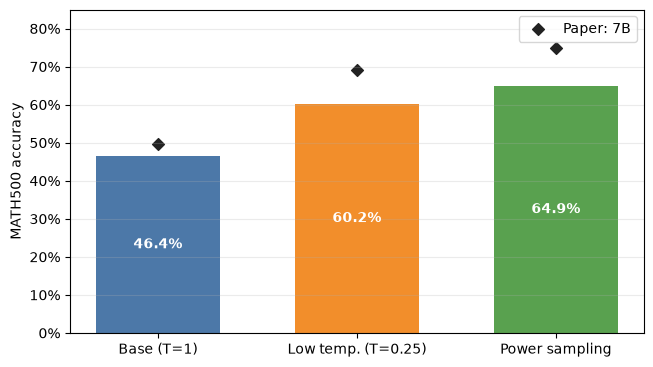

In [2]:
metrics = pd.DataFrame(summary["aggregates"]).T.loc[methods]
display(metrics[["seeds", "accuracy", "math_verify_accuracy", "parse_rate"]].style.format({
    "accuracy": "{:.1%}", "math_verify_accuracy": "{:.1%}", "parse_rate": "{:.1%}"
}))

paper_7b = summary["paper_qwen_math_7b"]
x = np.arange(3)
fig, ax = plt.subplots(figsize=(7.4, 4.2))
values = metrics.accuracy.to_numpy()
bars = ax.bar(x, values, color=["#4C78A8", "#F28E2B", "#59A14F"], width=.62)
ax.scatter(x, [paper_7b[m] for m in methods], marker="D", color="#222", label="Paper: 7B")
ax.bar_label(bars, labels=[f"{v:.1%}" for v in values], label_type="center", color="white", fontweight="bold")
ax.set(xticks=x, xticklabels=[labels[m] for m in methods], ylabel="MATH500 accuracy", ylim=(0, .85))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.grid(axis="y", alpha=.25); ax.legend(); plt.show()

In [3]:
comparison = pd.DataFrame(summary["comparisons"]).T
comparison["effect_pp"] = comparison.difference * 100
comparison["95% CI (pp)"] = comparison.ci95.map(lambda x: f"[{100*x[0]:.1f}, {100*x[1]:.1f}]")
comparison[["seeds", "effect_pp", "95% CI (pp)"]].style.format({"effect_pp": "{:+.1f}"})

,seeds,effect_pp,95% CI (pp)
low_temp_minus_base,"[0, 1]",+13.8,"[10.1, 17.4]"
power_minus_base,"[0, 1]",+18.5,"[14.7, 22.3]"
power_minus_low_temp,"[0, 1]",+4.7,"[1.8, 7.7]"


Power sampling improves over low-temperature sampling on the observed seed(s). The paired bootstrap resamples questions; with few decoding seeds it does **not** quantify seed-to-seed uncertainty.

## Sampling cost and chain behavior

In [4]:
cost = metrics[["response_tokens", "sampled_tokens", "acceptance_rate"]].copy()
cost["sampling_overhead"] = cost.sampled_tokens / cost.response_tokens
display(cost.style.format({
    "response_tokens": "{:.0f}", "sampled_tokens": "{:.0f}",
    "acceptance_rate": "{:.1%}", "sampling_overhead": "{:.1f}x"
}))

,response_tokens,sampled_tokens,acceptance_rate,sampling_overhead
base,664,664,0.0%,1.0x
low_temp,653,653,0.0%,1.0x
power,628,9861,59.7%,15.7x


Power sampling is not a matched-compute baseline: it returns one answer but samples many suffix tokens. The relevant comparison is single-shot answer quality, with sampled-token overhead reported explicitly.

<div style="break-before: page;"></div>

## What changed on the same questions?

In [5]:
groups = load_groups()
low, power = groups["low_temp", 0], groups["power", 0]
transition = pd.crosstab(
    pd.Series([low[i]["paper_correct"] for i in range(500)], name="Low temp."),
    pd.Series([power[i]["paper_correct"] for i in range(500)], name="Power")
)
transition

Power,False,True
Low temp.,,
False,130,67
True,44,259


In [6]:
example_ids = [468, 58, 457, 433, 262, 12]
pd.DataFrame([{
    "id": i,
    "target": low[i]["ground_truth"],
    "low-temp answer": low[i]["parsed_answer"],
    "power answer": power[i]["parsed_answer"],
    "low correct": low[i]["paper_correct"],
    "power correct": power[i]["paper_correct"],
} for i in example_ids])

,id,target,low-temp answer,power answer,low correct,power correct
0,468,8,7,8,False,True
1,58,9901,"10,000",9901,False,True
2,457,0,NaN,0,False,True
3,433,.35625,0.35625,NaN,True,False
4,262,4,4,NaN,True,False
5,12,284,284,NaN,True,False


The paired examples show two mechanisms. Power sampling sometimes replaces a flawed derivation (an off-by-one count or false algebraic identity) with a correct one. It also changes termination and format compliance: some gains come from adding the required box, while some losses are mathematically correct but omit it. See `../reports/QUALITATIVE_EXAMPLES.md` for the full case discussion.

## Conclusion and limits

The two-seed 1.5B study reproduces the paper's ordering—power sampling > low temperature > base—without training or changing model weights. This supports the narrower claim that sequence-level sharpening can improve this model's sampled MATH500 answers. It does not establish equivalence to a larger model or RL, and the large generation overhead makes it a quality–compute trade-off rather than a free improvement.